# 05-CNN

In den vorherigen Kapiteln wurden neuronale Netze anhand von Eingabevektoren eingeführt: Jedes Beispiel wurde als eindimensionaler Vektor an das Netz übergeben. Bilder hingegen sind von Natur aus zweidimensional – sie bestehen aus einer $n \times m$ Matrix von Pixelwerten. Ein Farbbild hat zusätzlich drei solcher Matrizen (Kanäle), eine für Rot, Grün und Blau. Ein vollständig verbundenes Netz, das ein solches Bild verarbeiten soll, müsste alle Pixelwerte in einen langen Vektor umwandeln. Das führt bei realistischen Bildgrößen schnell zu einer sehr großen Anzahl von Gewichten und damit zu hohem Rechenaufwand sowie Overfitting. Convolutional Neural Networks (CNNs) begegnen diesem Problem mit einem anderen Ansatz, der sich an der Funktionsweise des menschlichen Sehsystems orientiert.

# Convolutional Neural Networks (CNN)

CNNs sind besonders geeignet für die Verarbeitung von Bilddaten, da sie die räumliche Struktur von Bildern ausnutzen. Statt jedes Pixel mit jedem Neuron zu verbinden, reagiert jedes Neuron in einem Convolutional Layer nur auf einen lokalen Bildausschnitt. Dadurch bleibt die Anzahl der Parameter beherrschbar, selbst bei hochauflösenden Bildern. Wie bei den bisher betrachteten neuronalen Netzen erfolgt das Training auch bei CNNs über Backpropagation.

## Bilderkennung im Hirn

Das Prinzip der CNNs ist von der Verarbeitung visueller Reize im menschlichen Gehirn inspiriert. Im visuellen Kortex reagieren viele Neuronen nicht auf das gesamte Sichtfeld, sondern nur auf einen begrenzten Bereich – das sogenannte rezeptive Feld. Dabei können sich die Wahrnehmungsfelder benachbarter Neuronen überlappen. Verschiedene Neuronen spezialisieren sich auf unterschiedliche Muster: Manche reagieren auf horizontale Kanten, andere auf Kurven oder bestimmte Texturen. In höheren Hirnarealen gibt es dann Neuronen mit größeren Wahrnehmungsfeldern, die komplexere Merkmale aus der Kombination einfacherer Muster erkennen – etwa ganze Objekte oder Gesichter.

Genau diese hierarchische Verarbeitung spiegelt sich im Aufbau von CNNs wider.

## Was bedeutet Konvolution?

Mathematisch bezeichnet Konvolution (deutsch: Faltung) die Verknüpfung zweier Funktionen zu einer dritten. Für zwei kontinuierliche Funktionen $f$ und $g$ ist die Faltung definiert als

$$(f * g)(t) = \int_{-\infty}^{\infty} f(\tau)\, g(t - \tau)\, d\tau$$

Im diskreten Fall – wie bei digitalen Bildern – lautet die entsprechende Formel

$$(f * g)[n] = \sum_{k=-\infty}^{\infty} f[k]\, g[n - k]$$

Im Kontext von Bildern wird die Faltung auf zweidimensionale Matrizen angewendet: Ein sogenannter Filter (auch Kernel genannt) wird über das Bild verschoben und an jeder Position elementweise mit dem Bildausschnitt multipliziert und aufsummiert. Durch die Wahl des Filters lassen sich gezielt bestimmte Bildmerkmale hervorheben – beispielsweise horizontale Kanten mit einem Linienfilter, Übergänge zwischen hellen und dunklen Bereichen mit einem Kantenfilter oder eine Glättung des Bildes mit einem Gaußfilter.

## Aufbau eines CNN

<figure  style="text-align: center;">
    <img src="Bilder/CNN_eigen.png" alt="Aufbau eines CNN" width = 700>
    <figcaption>Aufbau eines CNN mit Kodierungs- und Prädiktionsblock.</figcaption>
</figure>

Eingabebild --> Kodierungsblock --> Prädiktionsblock

### Eingabebild

Das Bild besteht im einfachsten Fall (schwarz-weiss) aus eine $n\times m$ Matrix, die Werte der Matrix entsprechen der Helligkeit der Pixel

#### Aufgabe

Bild einlesen und Matrix darstellen.

Größe des Bildes: (2048, 1536, 3)


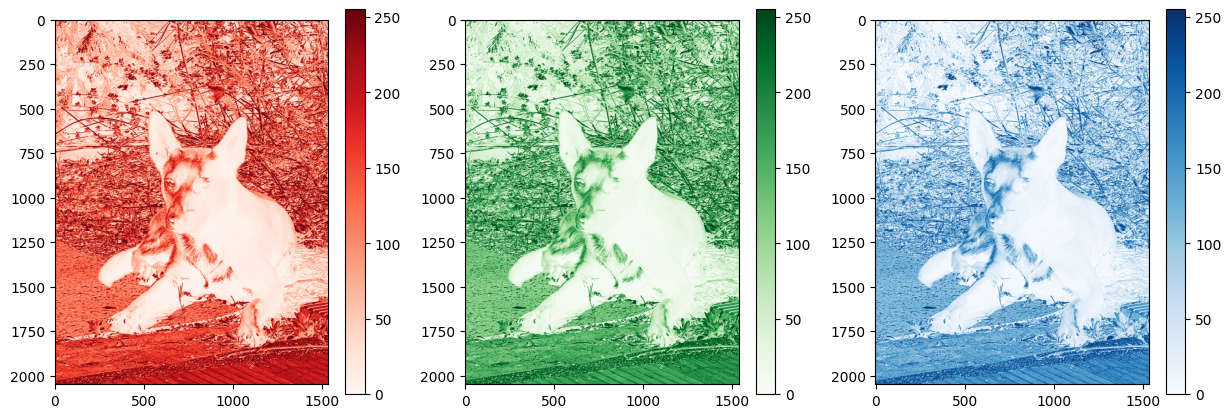

In [1]:
import numpy as np
import matplotlib.pyplot as plt

img = plt.imread('Bilder/Hund.jpeg')

print('Größe des Bildes:', img.shape)

fig, [ax1,ax2,ax3] = plt.subplots(1,3, figsize=(15, 5))
plot1 = ax1.imshow(img[:,:,0], cmap = 'Reds')
plot2 = ax2.imshow(img[:,:,1], cmap = 'Greens')
plot3 = ax3.imshow(img[:,:,2], cmap = 'Blues')
fig.colorbar(plot1)
fig.colorbar(plot2)
fig.colorbar(plot3)

### Kodierungsblock

Besteht aus Convolutional Layer, Aktivierungsfunktion und Pooling Layer

#### Convolutional Layer

Ein Convolutional Layer besteht aus einer Menge von Perzeptronen, die jeweils mit einem Filter auf einen Bildausschnitt reagieren. 
Typischerweise sind die Bildausschnitte $3\times 3$ oder $5\times 5$ Matrizen. Alle Perzeptronen reagieren auf ein Muster (beispielsweise horizontale Line, oder Kante). Das Muster ist durch den Filter definiert. 
Um auf verschiedene Muster reagieren zu können werden mehrere Ebenen (= Feature Maps) benötigt, eine für jedes Muster.

Für alle Perzeptronen $c_{i,j}$ in der ersten Ebene eines Convolutional Layer gilt für die Pixel e_{l,m} und einem $3\times 3$ Filter

$$c_{i,j} = w_1 e_{i-1,j-1} + w_2 e_{i-1,j} + w_3 e_{i-1,j+1} + w_4 e_{i,j-1} + w_5 e_{i,j} + w_6 e_{i,j+1} + w_7 e_{i+1,j-1} + w_8 e_{i+1,j} + w_9 e_{i+1,j+1}$$

$w_1$ bis $w_9$ sind dabei für jedes Perzeptron gleich.

Die einzelnen Filter dürfen sich überlappen.

#### Aufgabe 1

Wie sieht die Funktion $c_{i,j}$ für einen $5\times 5$ Filter aus?

#### Aktivierungsfunktion

Meist verwendete Aktivierungsfunktion ist 

$$\text{ReLu}(x) = max(0,x)$$

da sie sehr schnell zu berechnen ist.

#### Aufgabe 2

Wie lautete die Ableitung von ReLU?

#### Pooling

Der Pooling Layer folgt unmittelbar nach der Aktivierungsfunktion und dient der Dimensionsreduktion der Feature Maps. Durch die Verkleinerung der räumlichen Ausdehnung sinkt der Rechenaufwand für die nachfolgenden Schichten, und das Modell wird robuster gegenüber kleinen Verschiebungen oder Verzerrungen im Eingabebild.

Ein Pooling-Filter (typischerweise $2\times 2$ oder $3\times 3$) wird über die Feature Map geschoben und fasst jeweils einen lokalen Bildausschnitt zu einem einzigen Wert zusammen. Im Unterschied zum Convolutional Layer gibt es dabei **keine lernbaren Gewichte** – die Zusammenfassung erfolgt nach einer festen Regel.

Ein weiterer Unterschied ist, dass die Pooling-Filter **nicht überlappen**: Der Filter wird in Schritten verschoben, deren Größe der Filtergröße entspricht (Stride = Filtergröße). Bei einem $2\times 2$-Filter springt das Fenster also jeweils zwei Pixel weiter, sodass jeder Bildausschnitt genau einmal verarbeitet wird und die Ausgabe in jeder Dimension halbiert wird.

Die häufigste Variante ist **Max Pooling**: Aus jedem Bildausschnitt wird der maximale Wert ausgewählt und weitergegeben. Für einen Filter der Größe $k\times k$ gilt

$$p_{i,j} = \max_{0 \leq r,\, s \,< k} \; e_{\,i \cdot k + r,\; j \cdot k + s}$$

wobei $e_{i,j}$ der Wert an Position $(i,j)$ in der Feature Map ist.

**Beispiel:** Eine $4\times 4$ Feature Map, verarbeitet mit einem $2\times 2$ Max-Pool-Filter:

$$\begin{pmatrix} 1 & 3 & 2 & 4 \\ 5 & 6 & 1 & 2 \\ 3 & 2 & 8 & 7 \\ 1 & 4 & 6 & 5 \end{pmatrix} \xrightarrow{\;\text{Max Pool } 2\times 2\;} \begin{pmatrix} 6 & 4 \\ 4 & 8 \end{pmatrix}$$

Aus $4\times 4 = 16$ Werten werden $2\times 2 = 4$ – die räumliche Auflösung wurde halbiert, die stärksten Aktivierungen bleiben erhalten.

Neben Max Pooling gibt es auch **Average Pooling**, bei dem anstelle des Maximums der Durchschnitt der Werte im Ausschnitt gebildet wird. Average Pooling erzeugt eine gleichmäßigere Repräsentation, wird aber seltener eingesetzt als Max Pooling.

#### Achtung an Randbereichen

Wenn ein Filter der Größe $k \times k$ über ein Bild geschoben wird, entsteht an den Rändern ein Problem: Der Filter würde über den Bildrand hinausragen und findet keinen vollständigen Bildausschnitt mehr. Es gibt zwei grundlegende Strategien, damit umzugehen.

Bei **Valid Padding** (kein Auffüllen) wird der Filter nur an Positionen angewendet, an denen er vollständig innerhalb des Bildes liegt. Die Ausgabe ist dadurch kleiner als die Eingabe. Allgemein gilt für die Ausgabegröße bei einer $n \times n$ Eingabe, einem $k \times k$ Filter, Padding $p$ und Stride $s$:

$$\text{Ausgabegröße} = \left\lfloor \frac{n - k + 2p}{s} \right\rfloor + 1$$

Bei Valid Padding ist $p = 0$. So ergibt sich beispielsweise aus einem $28 \times 28$ Bild nach einem $5 \times 5$ Filter mit Stride $1$:

$$\left\lfloor \frac{28 - 5 + 0}{1} \right\rfloor + 1 = 24$$

Die Ausgabe hat also Größe $24 \times 24$ — genau wie im `model.summary()` des Notebooks zu sehen.

Bei **Same Padding** (Zero Padding) wird das Bild vor der Filteranwendung mit Nullen aufgefüllt, sodass die Ausgabe dieselbe räumliche Größe wie die Eingabe behält. Dazu wird auf jeder Seite ein Rand der Breite $p = \lfloor k/2 \rfloor$ aus Nullen ergänzt.

**Beispiel:** Eine $4 \times 4$ Matrix mit Same Padding ($p = 1$) für einen $3 \times 3$ Filter:

$$\begin{pmatrix} 1 & 2 & 3 & 4 \\ 5 & 6 & 7 & 8 \\ 9 & 10 & 11 & 12 \\ 13 & 14 & 15 & 16 \end{pmatrix} \xrightarrow{\;\text{Zero Padding}\;} \begin{pmatrix} 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 1 & 2 & 3 & 4 & 0 \\ 0 & 5 & 6 & 7 & 8 & 0 \\ 0 & 9 & 10 & 11 & 12 & 0 \\ 0 & 13 & 14 & 15 & 16 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 \end{pmatrix}$$

Die erweiterte $6 \times 6$ Matrix kann nun mit einem $3 \times 3$ Filter vollständig abgetastet werden, und die Ausgabe hat wieder die ursprüngliche Größe $4 \times 4$.

Neben Valid und Same Padding gibt es weitere Varianten, bei denen die Randpixel beispielsweise gespiegelt oder wiederholt werden. In der Praxis sind Valid und Same Padding jedoch die am häufigsten verwendeten Methoden.

### Prädiktionsblock

Nachdem der Kodierungsblock die räumlichen Merkmale des Bildes extrahiert hat, übernimmt der Prädiktionsblock die eigentliche Klassifikation. Er entspricht in seinem Aufbau dem vollverbundenen Netz, das bereits in den vorangegangenen Kapiteln eingeführt wurde.

#### Flatten

Als erstes müssen die Feature Maps des Kodierungsblocks in einen eindimensionalen Vektor umgewandelt werden, da vollverbundene Schichten Vektoren als Eingabe erwarten. Dieser Schritt wird als **Flatten** bezeichnet. Im Notebook liefert der letzte Pooling Layer Feature Maps der Größe $4 \times 4$ mit 64 Kanälen — das ergibt einen Eingabevektor der Länge

$$4 \times 4 \times 64 = 1024$$

wie im `model.summary()` des Notebooks zu sehen.

#### Fully Connected Network

Der Vektor wird anschließend als Eingabe in ein vollverbundenes Netzwerk gegeben, wie es in den Kapiteln 03 und 04 beschrieben wurde.

#### Ausgabeschicht

Es werden so viele Ausgabeneuronen benötigt, wie es Klassen gibt — im vorliegenden Beispiel 10, eine für jede Ziffer von 0 bis 9. Die Zielwerte werden dabei als One-Hot-Vektor kodiert (z.B. die Ziffer 3 als $[0,0,0,1,0,0,0,0,0,0]$). Als Verlustfunktion wird `categorical_crossentropy` verwendet, die genau auf dieses Format ausgelegt ist.

Für die letzte Schicht bietet sich die **Softmax**-Funktion an:

$$f_{\text{Softmax}}(c_j) = \frac{e^{c_j}}{\sum_{i=1}^{k} e^{c_i}}$$

Softmax transformiert die Ausgaben des Netzes in einen Wertebereich zwischen 0 und 1, wobei alle Werte zusammen genau 1 ergeben – sie lassen sich damit direkt als Wahrscheinlichkeiten für die einzelnen Klassen interpretieren.

### Optimierung - oder wer ist Adam?

Das Training eines neuronalen Netzes erfolgt über Backpropagation und Gradientenabstieg, wie bereits in Kapitel 03 beschrieben. Der einfache Gradientenabstieg hat dabei jedoch einige praktische Schwächen: Er verwendet für alle Gewichte dieselbe Lernrate, ist empfindlich gegenüber deren Wahl, und kann in flachen Bereichen der Fehlerfunktion – etwa an Sattelpunkten oder langen Plateaus – nur langsam vorankommen. **Optimierer** sind Algorithmen, die den Gradientenabstieg gezielter gestalten: Sie verändern, wie die Gewichte in jedem Schritt angepasst werden, sodass das Training schneller und zuverlässiger konvergiert.

#### Adam (Adaptive Moment Estimation)

Adam ist einer der am häufigsten verwendeten Optimierer und kombiniert zwei zentrale Ideen:

**Momentum:** Statt nur dem aktuellen Gradienten zu folgen, berücksichtigt Adam auch die vergangenen Gradienten in Form eines gleitenden Mittelwerts. Das ist vergleichbar mit einem Ball, der eine Kurve hinunterrollt und durch seine Trägheit kleinere Unebenheiten überwindet, anstatt bei jedem Hindernis abzubremsen. Dadurch werden Schwingungen in der Lernkurve gedämpft und Sattelpunkte leichter überwunden.

**Adaptive Lernraten:** Adam passt die Lernrate für jedes Gewicht individuell an. Gewichte, die in letzter Zeit große Gradienten hatten, werden in kleineren Schritten angepasst; Gewichte mit kleinen Gradienten erhalten eine größere effektive Schrittweite. Das sorgt dafür, dass seltene, aber informative Merkmale nicht ignoriert werden.

In der Praxis wird Adam mit folgenden Standardwerten verwendet, die für die meisten Aufgaben gut funktionieren:

| Parameter | Bedeutung | Standardwert |
|-----------|-----------|:---:|
| $\beta_1$ | Gewichtung des Momentum (gleitender Mittelwert der Gradienten) | $0.9$ |
| $\beta_2$ | Gewichtung der adaptiven Lernrate (gleitender Mittelwert der quadrierten Gradienten) | $0.999$ |
| $\varepsilon$ | Kleiner Wert zur numerischen Stabilität (verhindert Division durch Null) | $10^{-8}$ |
| Lernrate | Globale Schrittweite | $0.001$ |

Im Notebook wird Adam mit `optimizer='adam'` aufgerufen, was genau diese Standardwerte verwendet.

# Zahlen erkennen reloaded

In [2]:
#| code-fold: true
#| code-summary: "Code anzeigen"


import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import re
import cv2

# Funktion zur numerischen Sortierung der Dateien
def extract_number(filename):
    return int(re.search(r"_sortiert(\d+)", filename).group(1))

# Alle Files einleden, die mit Zahlen_Handschrift_sortiert beginnen und direkt darauf folgend eine Zahl im Namen haben.
liste_daten = glob('Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert*[0-9].png')

# Liste numerisch sortieren und sortierte Liste ausgeben
liste_daten = sorted(liste_daten, key=extract_number)
for el in liste_daten:
    print(el)

Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert01.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert02.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert03.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert04.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert05.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert06.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert07.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert08.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert09.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert10.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert11.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert12.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert13.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert14.png


In [1]:
#| code-fold: true
#| code-summary: "Code anzeigen"


def imshow(name, img, size=8):
    import matplotlib.pyplot as plt
    from IPython.display import display
    import cv2

    # Convert BGR to RGB
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img.shape[:2]
    aspect = w / h
    plt.figure(figsize=(size * aspect, size))
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.title(name)
    plt.axis('off')
    #plt.show()

# contours are not sorted, so sort them to assign the correct labels later
def sort_contours_grid(contours, row_height=50):
    # Extract bounding boxes
    bounding_boxes = [cv2.boundingRect(c) for c in contours]

    # Combine contours with their boxes
    contours_with_boxes = list(zip(contours, bounding_boxes))

    # First sort top-to-bottom by y
    contours_with_boxes.sort(key=lambda b: b[1][1])  # b[1][1] = y

    # Group contours into rows based on y
    rows = []
    current_row = []
    last_y = -row_height

    for c, (x, y, w, h) in contours_with_boxes:
        if y - last_y > row_height:
            if current_row:
                rows.append(current_row)
            current_row = [(c, (x, y, w, h))]
            last_y = y
        else:
            current_row.append((c, (x, y, w, h)))
    if current_row:
        rows.append(current_row)

    # Now sort each row left to right
    sorted_contours = []
    for row in rows:
        row.sort(key=lambda b: b[1][0])  # sort by x
        sorted_contours.extend([c for c, _ in row])

    return sorted_contours

Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert01.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert02.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert03.png
210 21.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert04.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert05.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert06.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert07.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert08.png
210 21.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert09.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert10.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert11.png
210 21.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert12.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert13.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert14.png
210 21.0


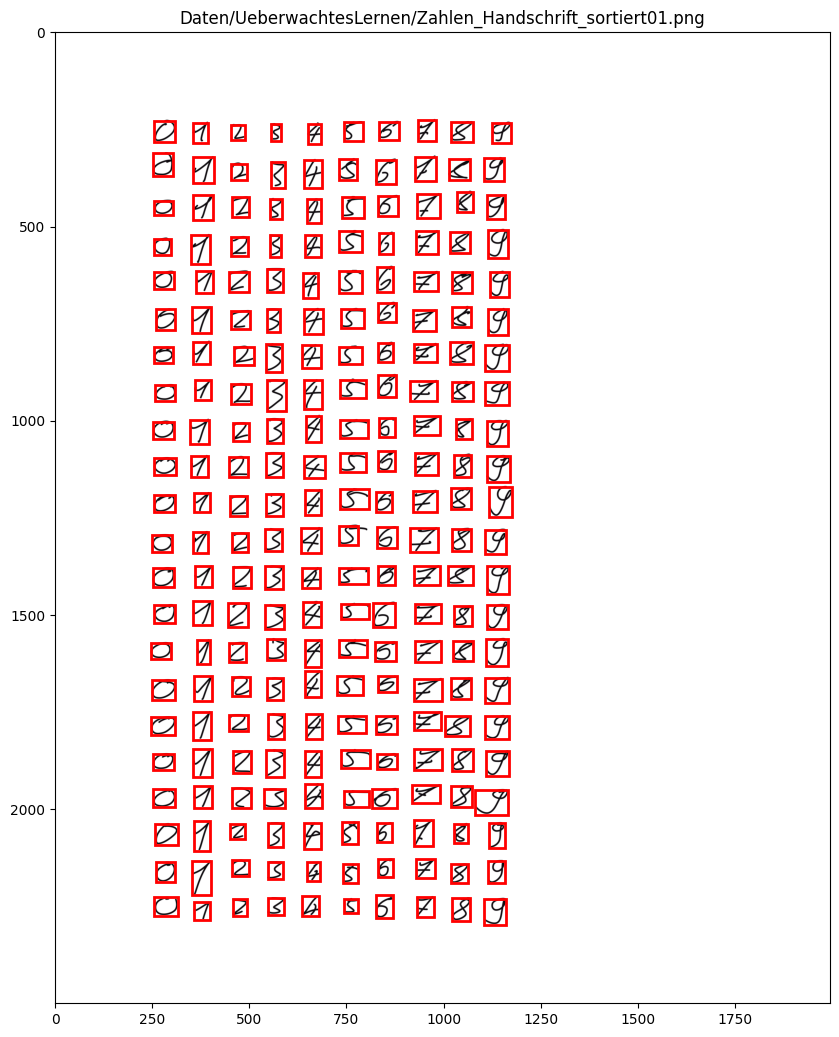

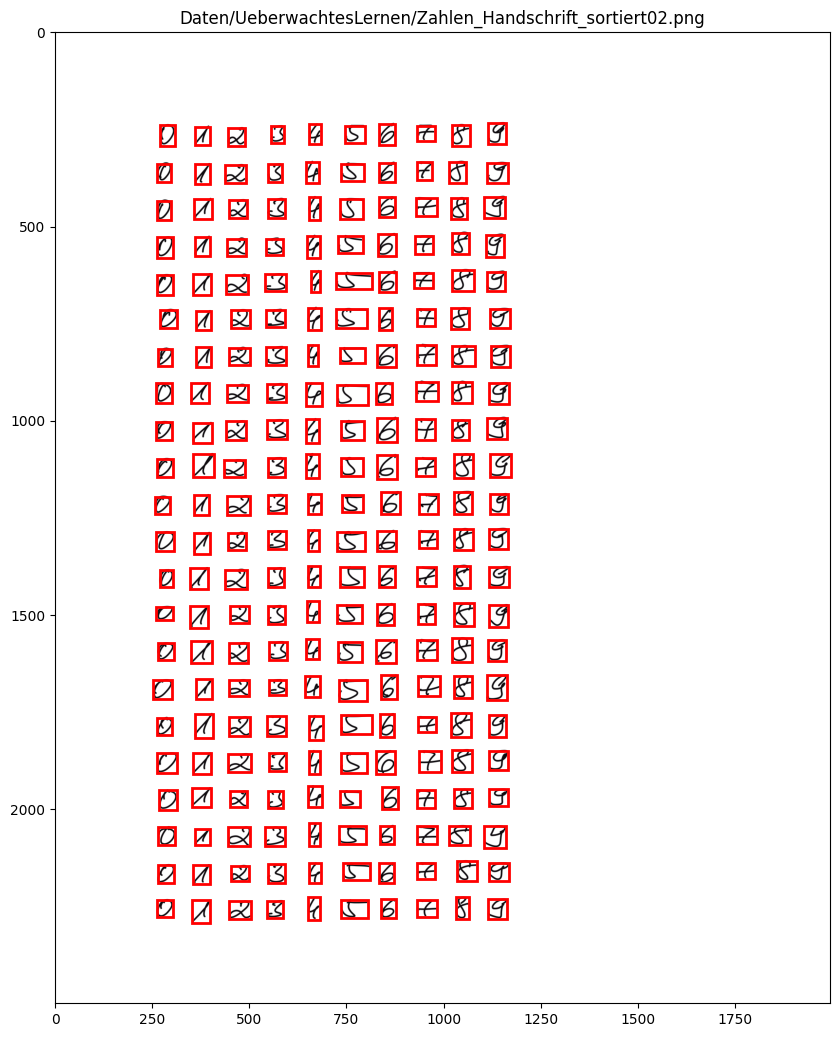

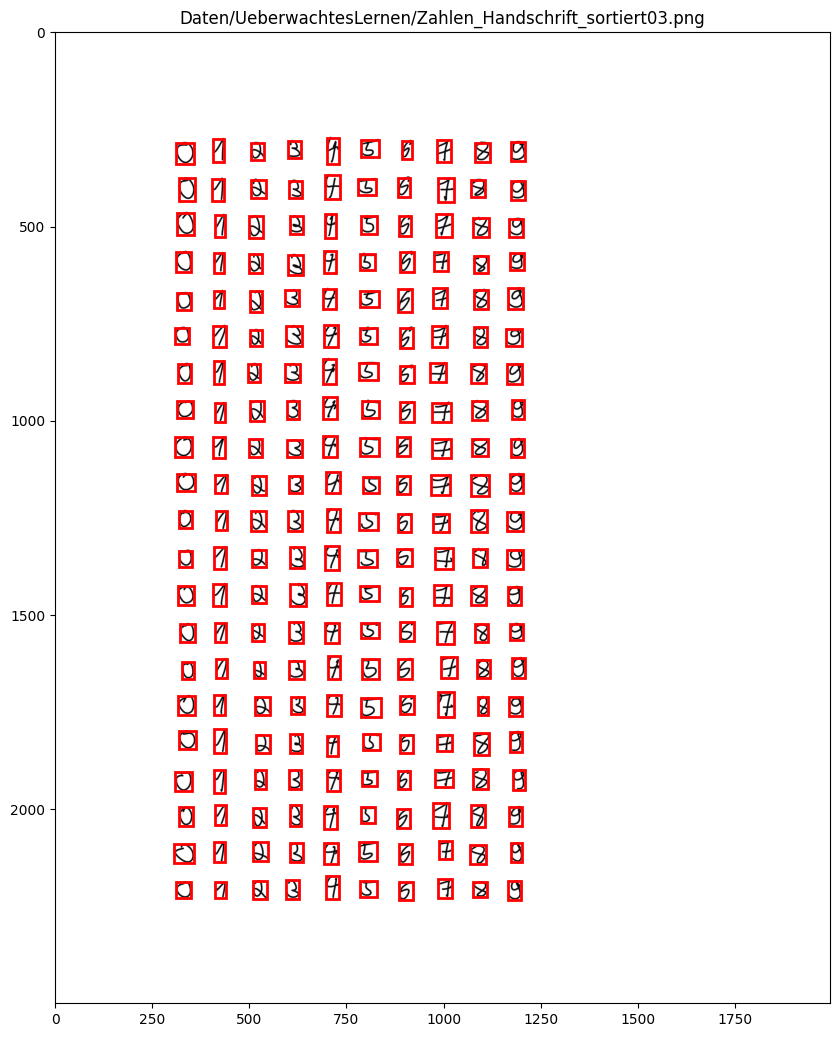

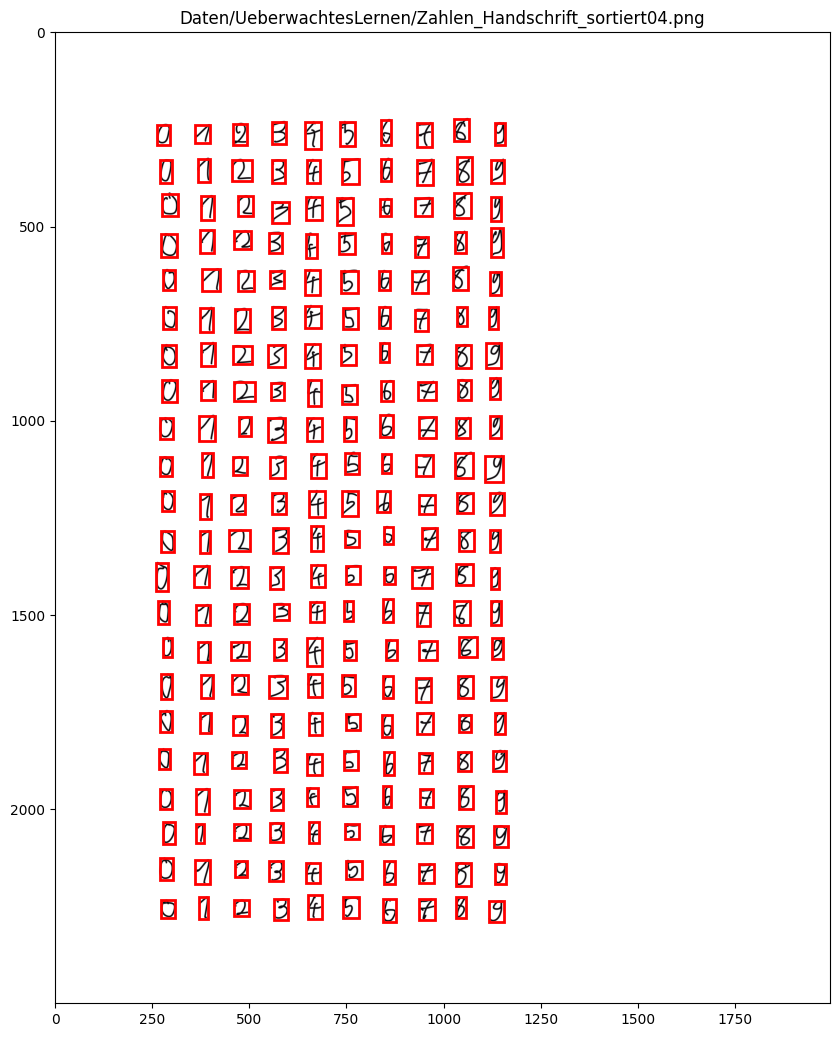

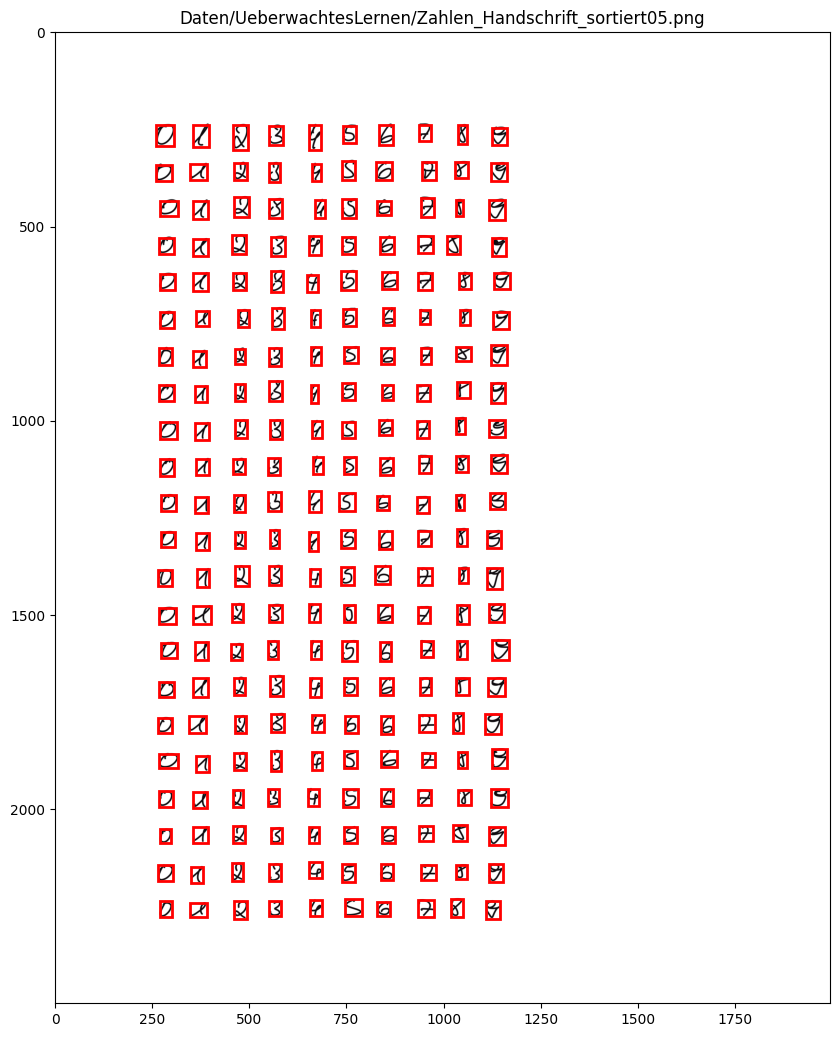

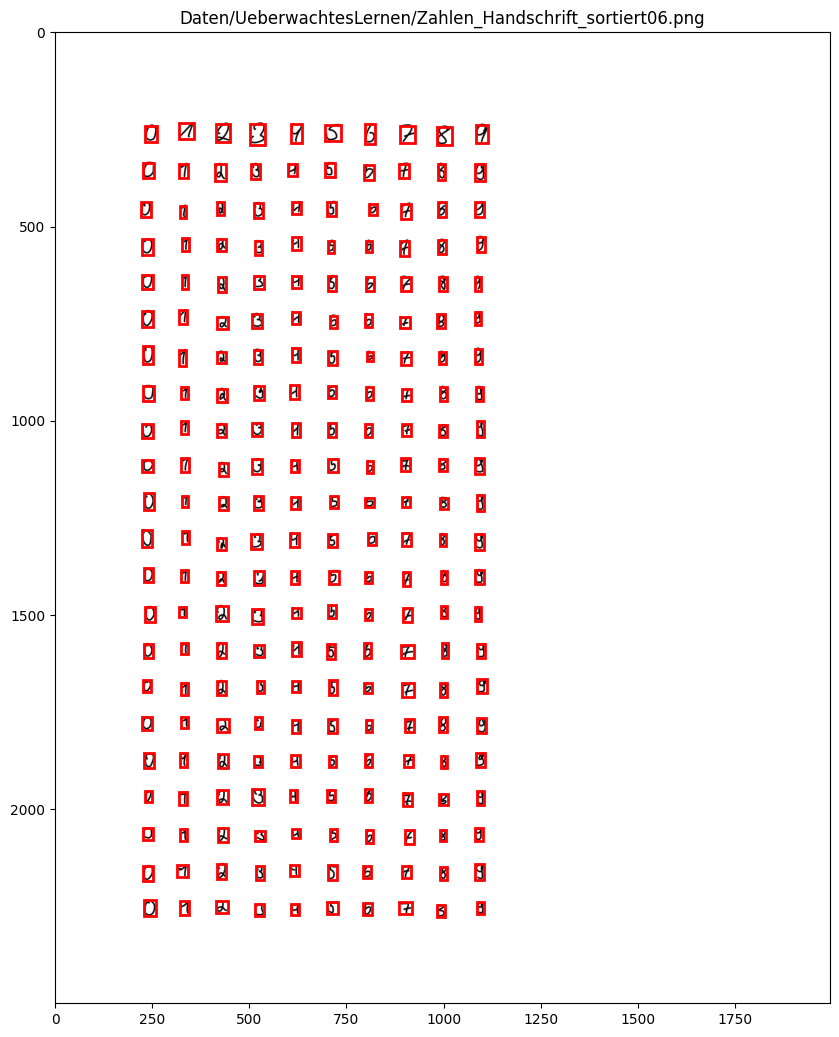

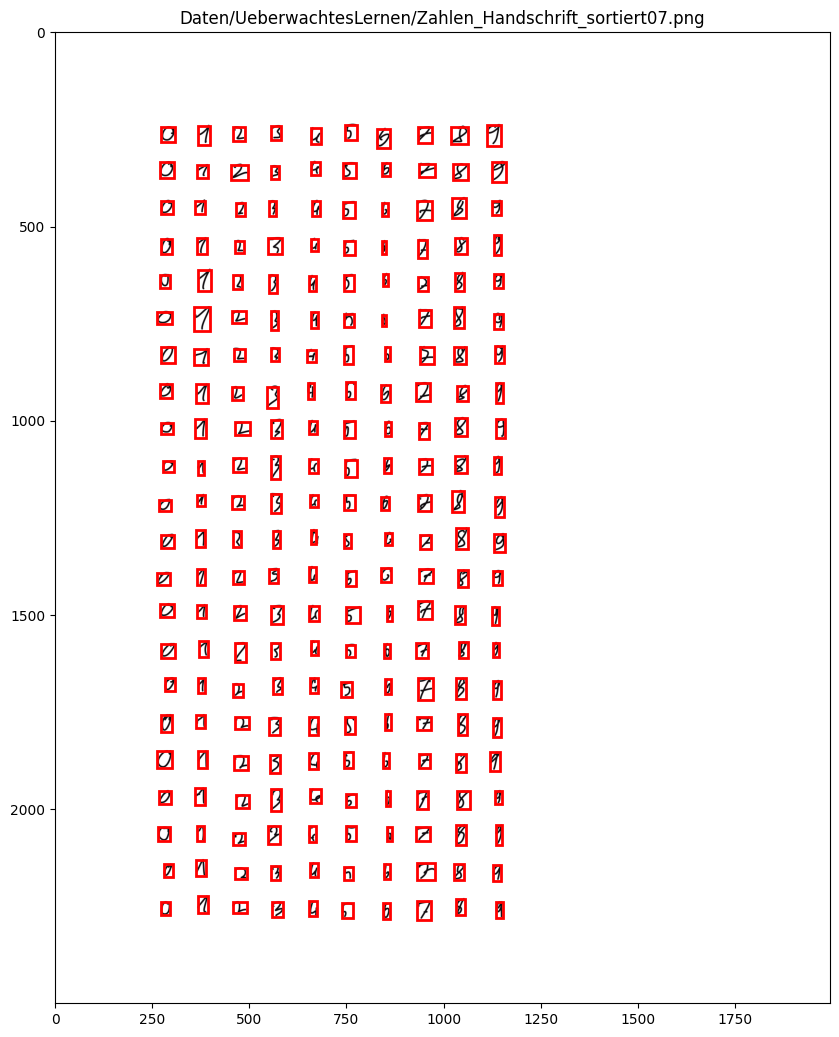

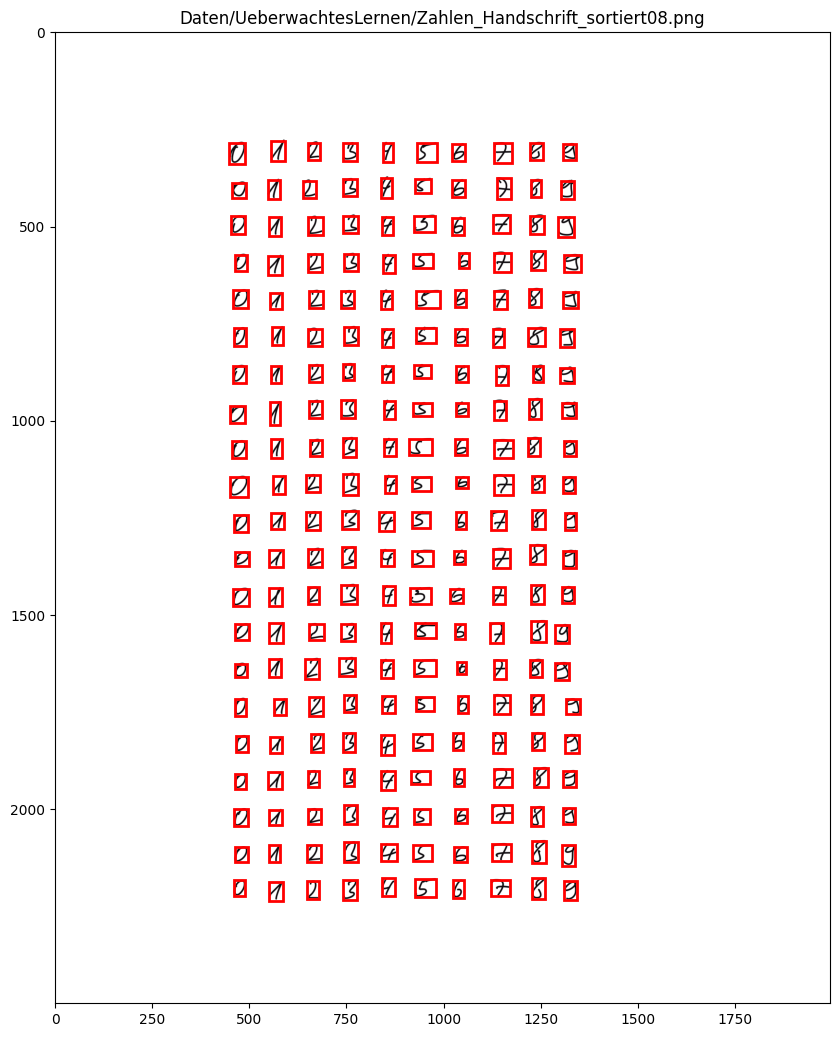

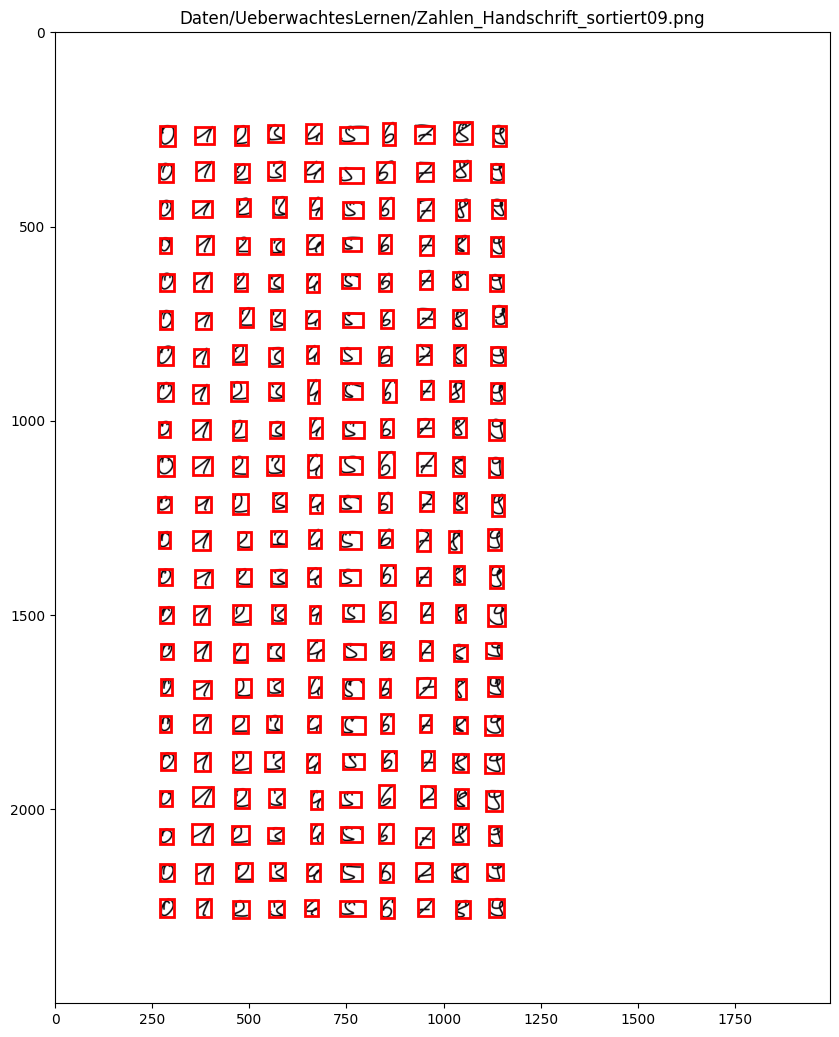

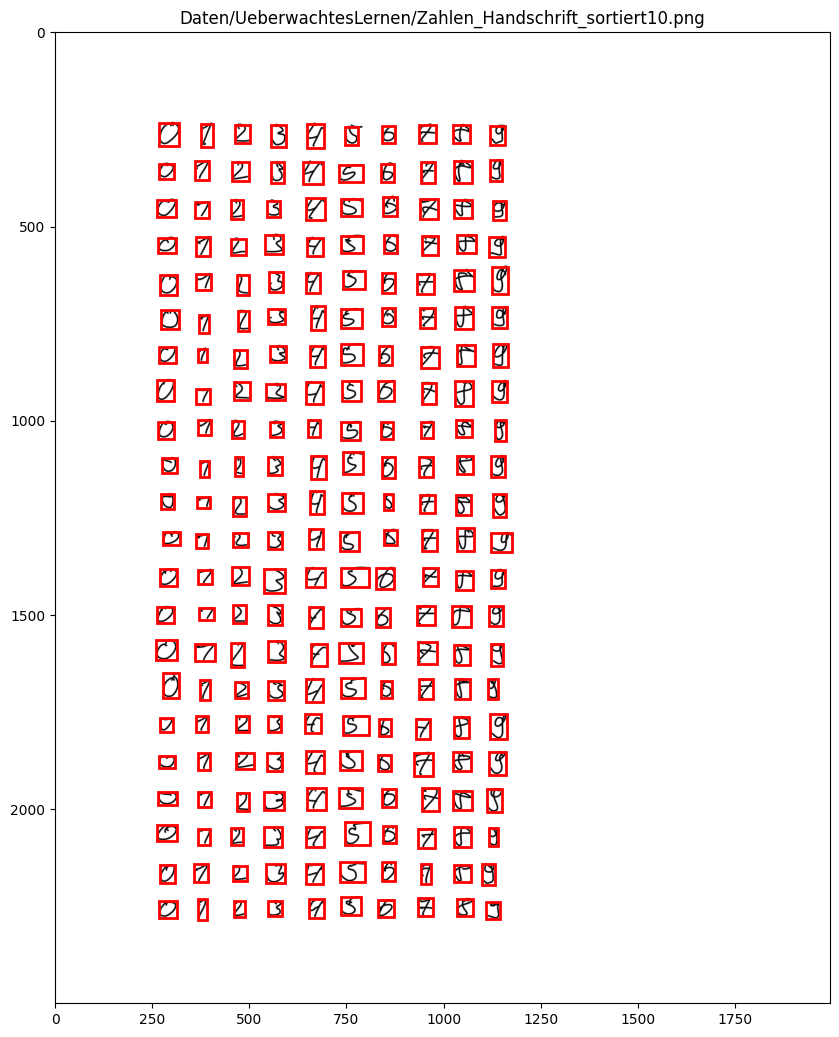

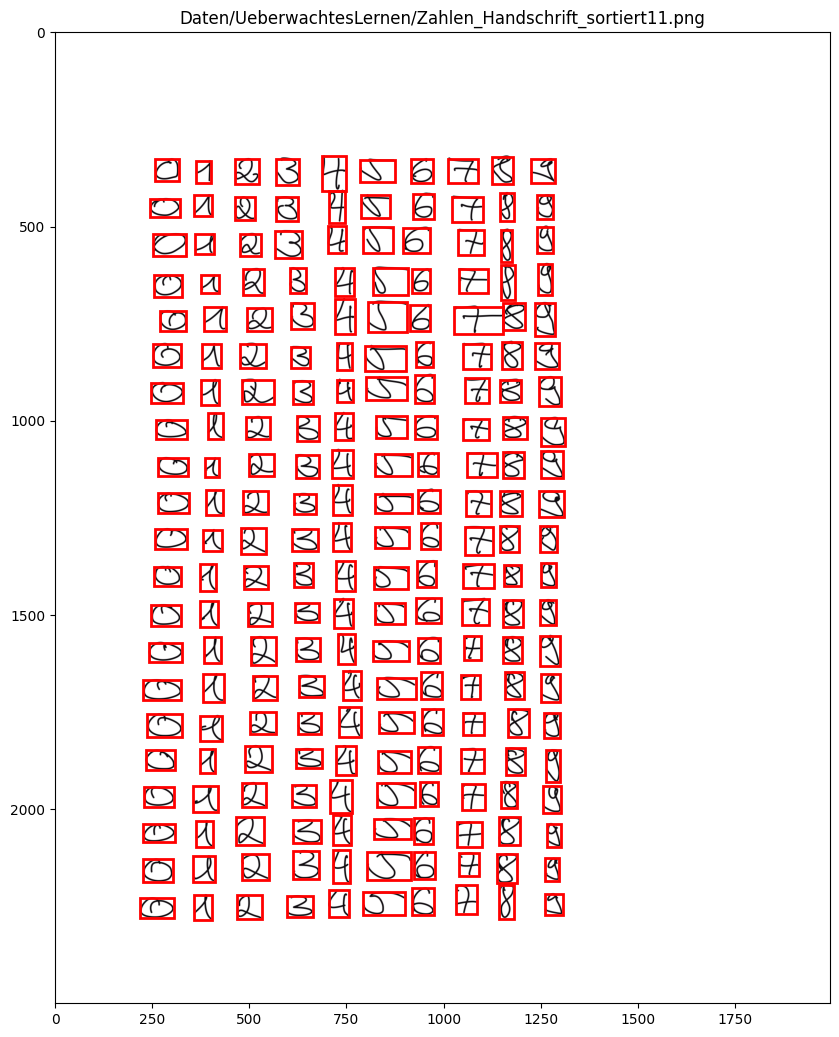

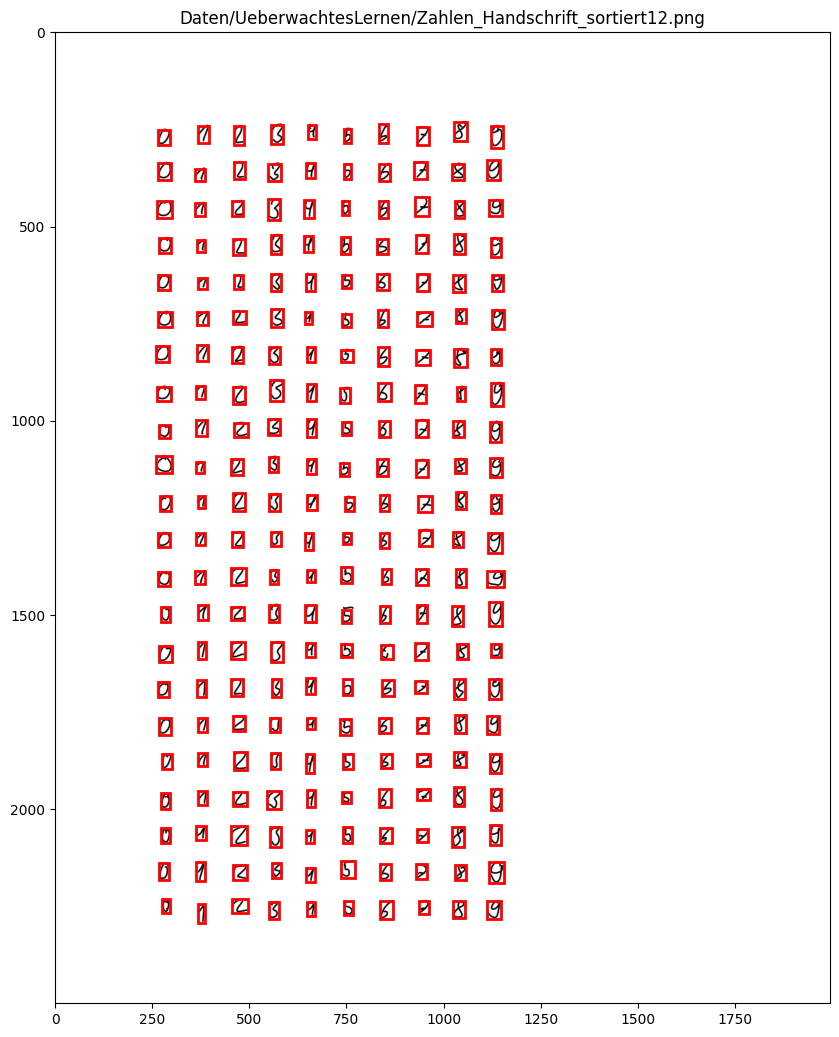

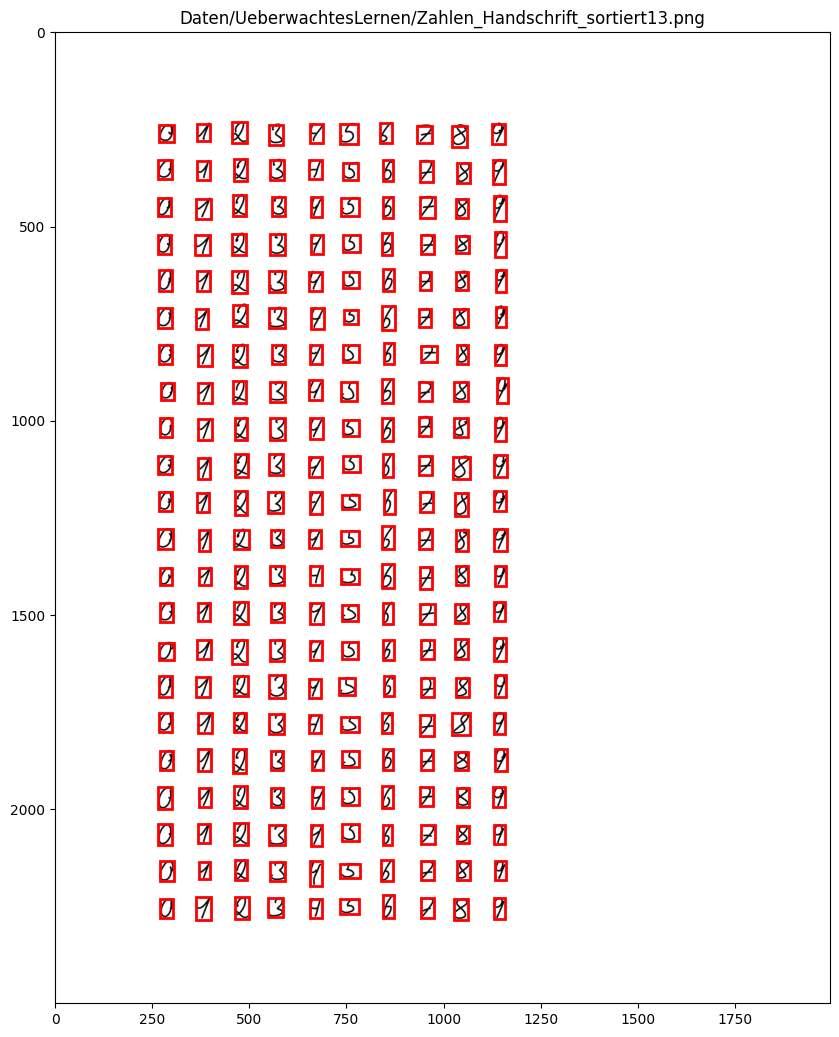

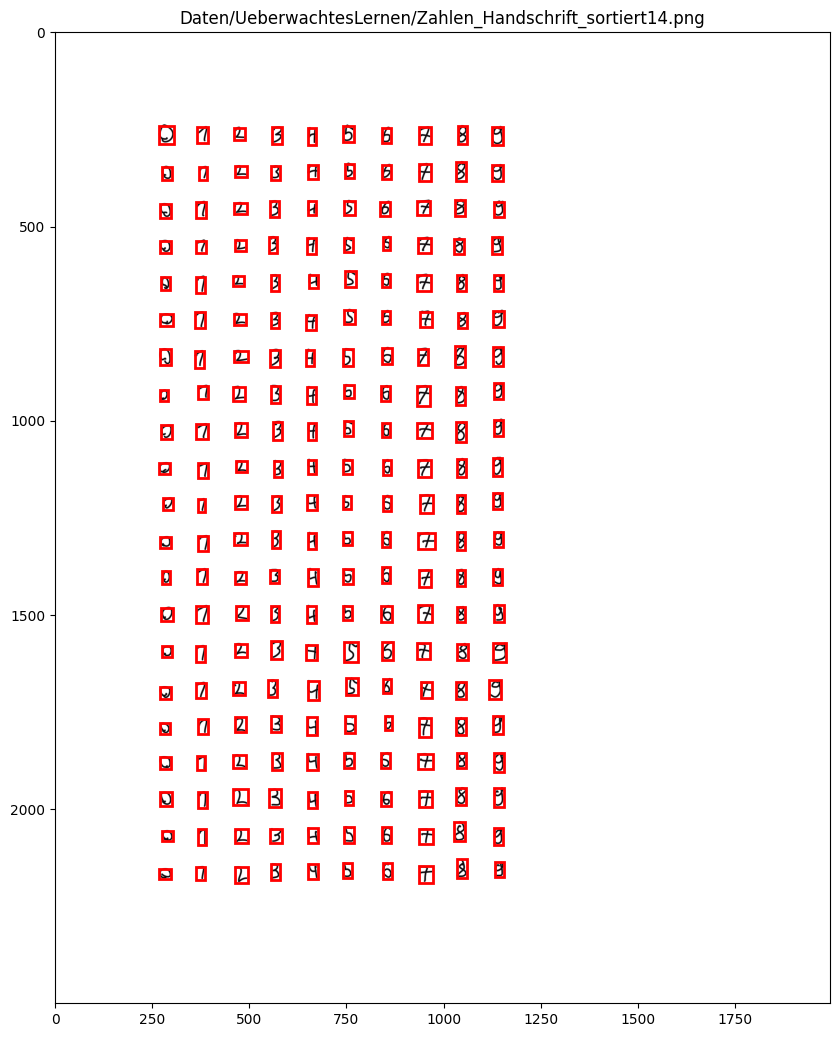

In [4]:
#| code-fold: true
#| code-summary: "Code anzeigen"

contour_height = 23

x_data_list = []
response_list = []

## Für die bessere Übersicht im Skript werden hier nur die ersten zwei Bilder ausgewertet. Wenn alle Bilder ausgewertet werden sollen, kommende Zeile auskommentieren und die alternative for-Schleife reinnehmen.
#for im in liste_daten[:2]:

## Alle Bilder auswerten
for im in liste_daten:

    print(im)
    image = cv2.imread(im)

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(5,5),0)
    thresh = cv2.adaptiveThreshold(blur,255,1,1,11,2)

    # find digits in image and create contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    no_digits = 0
    plt.figure(figsize = (10,15))
    plt.imshow(image, cmap='gray')
    plt.title(im)

    # jetzt rotes Viereck um jede Zahl zeichnen
    for cnt in contours:
        if cv2.contourArea(cnt) > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            if h > contour_height:
                no_digits +=1
                plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2))

    #Sortieren der Konturen von oben nach unten und links nach rechts
    contours = sort_contours_grid(contours)

    for cnt in contours:
        # print(cv2.contourArea(cnt))
        if cv2.contourArea(cnt) > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            if h > contour_height:
                roi = thresh[y:y+h, x:x+w]
                roismall = cv2.resize(roi, (28, 28))
                x_data_list.append(roismall)

    # now generate labels
    print(no_digits, no_digits/10)
    # create list of labels
    list_of_digits = [0,1,2,3,4,5,6,7,8,9]
    
    for element in range(int(no_digits/10)):
        response_list.append(list_of_digits)

#finalize the data
x_data = np.array(x_data_list)
response = np.array(response_list)
y_data = response.flatten()

In [5]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np

def split_array_randomly(x_arr, y_arr, train_ratio=0.8, seed=None):
    """
    Randomly split a NumPy array into two parts (train/test).
    
    Parameters:
        x_arr (np.ndarray): Input array with image data to split (any shape)
        y_arr (np.ndarray): Input array with label data to split (any shape)
        train_ratio (float): Fraction of data to go into first array (default: 0.8)
        seed (int): Optional random seed for reproducibility
        
    Returns:
        train_set, test_set (both np.ndarrays)
    """

    if seed is not None:
        np.random.seed(seed)
    try: 
        x_arr.shape[0] == y_arr.shape[0]
        print('ja')
    except:
        print('shape of arrays does not match')   

            
    # Generate shuffled indices
    indices = np.random.permutation(len(x_arr))
    split_point = int(len(x_arr) * train_ratio)

    train_idx = indices[:split_point]
    test_idx = indices[split_point:]
    train_idy = indices[:split_point]
    test_idy = indices[split_point:]

    return x_arr[train_idx], x_arr[test_idx], y_arr[train_idx], y_arr[test_idx]

x_train, x_test, y_train, y_test = split_array_randomly(x_data, y_data)


print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

np.savez('output/handwrittendigits.npz', array1=x_train, array2=x_test, array3=y_train, array4=y_test)

ja
(2432, 28, 28)
(608, 28, 28)
(2432,)
(608,)


In [ ]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import os
import numpy as np

from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import backend as K 
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

x_train = x_train.reshape((x_train.shape + (1,))) # Shape erweitern auf (60000, 28, 28, 1) = Channelinformation ='grey' hinzufügen, keras braucht das
x_train = x_train.astype('float32')
x_train = x_train/255      # Normalisierung

x_test = x_test.reshape((x_test.shape + (1,))) # Shape erweitern auf (60000, 28, 28, 1) = Channelinformation ='grey' hinzufügen, keras braucht das
x_test = x_test.astype('float32')
x_test = x_test/255        # Normalisierung

In [ ]:
#| code-fold: true
#| code-summary: "Code anzeigen"

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

NrTrainimages = x_train.shape[0]
NrTestimages = x_test.shape[0]

inputshape = x_train.shape[1:4]

model = Sequential()

# Kodierungsblock
## erster Block
model.add(Conv2D(32, kernel_size=(5,5), activation='relu', input_shape = inputshape)) # 5x5 Filter
model.add(MaxPooling2D(pool_size=(2,2)))                                              # 2x2 Filter
## zweiter Block
model.add(Conv2D(64, kernel_size = (5,5), activation='relu'))                          # 5x5 Filter
model.add(MaxPooling2D(pool_size=(2,2)))                                              # 2x2 Filter
model.add(Dropout(0.5))                                                               # zufällig werden 50 % der Neuronen deaktiviert

#Prädiktionsblock
model.add(Flatten())    #Matrix in Eingabevektor für Fully Connected umwandeln
model.add(Dense(128, activation = 'relu', name = 'features'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

/Users/simone/Documents/FH/Vorlesungen/KI/Test_KI_Vorlesung/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 192,202 (750.79 KB)

 Trainable params: 192,202 (750.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss = 'categorical_crossentropy',   # Lossfunktion, die sich für Klassifizierungen anbietet $\sum_j y_{i,j} log(\hat{y}_{i,j})$
              optimizer= 'adam',
              metrics = ['accuracy']
              )

In [9]:
LOGDIR = 'logs'
my_tensorboard = TensorBoard(log_dir = LOGDIR, histogram_freq = 0, write_graph = True, write_images = True)
my_batch_size = 128
my_num_classes = 10
my_epochs = 12

history = model.fit(x_train, y_train, 
                    batch_size=my_batch_size, 
                    callbacks=[my_tensorboard], 
                    epochs=my_epochs,verbose =1,
                    validation_data = (x_test, y_test)
                    )

Epoch 1/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2373 - loss: 2.1430 - val_accuracy: 0.5592 - val_loss: 1.5629
Epoch 2/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4951 - loss: 1.4799 - val_accuracy: 0.7730 - val_loss: 0.8091
Epoch 3/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7064 - loss: 0.9189 - val_accuracy: 0.8651 - val_loss: 0.4099
Epoch 4/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7965 - loss: 0.6302 - val_accuracy: 0.9145 - val_loss: 0.2970
Epoch 5/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8450 - loss: 0.4843 - val_accuracy: 0.9276 - val_loss: 0.2182
Epoch 6/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8795 - loss: 0.3748 - val_accuracy: 0.9490 - val_loss: 0.1529
Epoch 7/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8951 - loss: 0.3358 - val_accuracy: 0.9622 - val_loss: 0.1339
Epoch 8/12
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9132 - loss: 0.2702 - val_accuracy: 0.9638 - v

In [10]:
score = model.evaluate(x_test, y_test)
print('Test Verlust', score[0])
print('Test Genauigkeit', score[1])

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9753 - loss: 0.0999
Test Verlust 0.09990386664867401
Test Genauigkeit 0.9753289222717285


Text(0.5, 1.0, 'Model Accuracy')

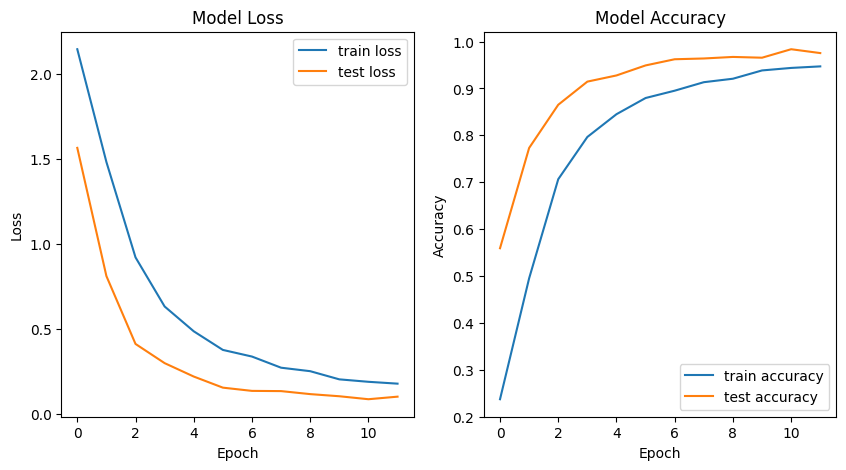

In [11]:
import matplotlib.pyplot as plt
fig, [ax1,ax2] = plt.subplots(1,2,figsize = (10,5))
#loss
ax1.plot(history.history['loss'], label='train loss')
ax1.plot(history.history['val_loss'], label='test loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Model Loss')
# Accuracy
ax2.plot(history.history['accuracy'], label='train accuracy')
ax2.plot(history.history['val_accuracy'], label='test accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Model Accuracy')

In [12]:
# ToDo: Vortrainiertes Netz nutzen für Rauch und Feuererkennung